# Uniform linear grating coupler

Grating couplers are optical components used to efficiently couple light between optical fibers (or free-space beams) and integrated photonic waveguides. They consist of a periodic structure—typically etched onto the surface of a photonic chip—that diffracts incoming light into the waveguide mode (or vice versa). Grating couplers are widely used in silicon photonics due to their ease of fabrication, compatibility with planar processes, and ability to support wafer-scale testing. 

The simplest form of the grating coupler is the uniform linear grating coupler. In this notebook, we demonstrate the design workflow of such a device based on the silicon on insulator (SOI) platform. Conventionally, the initial design starts in 2D for faster speed and lower cost. Once the grating coupler is optimized in 2D, we construct the 3D version and can then potentially perform additional optimization to enhance its coupling efficiency. 

<img src="img/grating_coupler_schematic.png" width="400" alt="Schematic of the grating coupler">

More advanced grating coupler designs, such as the [focusing apodized grating coupler](https://www.flexcompute.com/tidy3d/examples/notebooks/FocusedApodGC/) and the [inverse designed grating coupler](https://www.flexcompute.com/tidy3d/examples/notebooks/Autograd19ApodizedCoupler/), can be realized to achieve higher performance.

In [1]:
import matplotlib.pylab as plt
import numpy as np
import tidy3d as td
print(td.__version__)
import tidy3d.web as web

2.9.0


## Initial Design in 2D

We start with the 2D design and aim to optimize its coupling efficiency as much as possible. This way, the design process is faster and costs fewer FlexCredits.

First define the wavelength range of interest.

In [2]:
lda0 = 1.31  # central wavelength
freq0 = td.C_0 / lda0  # central frequency
ldas = np.linspace(1.25, 1.375, 201)  # wavelength range
freqs = td.C_0 / ldas  # frequency range
fwidth = 0.5 * (np.max(freqs) - np.min(freqs))  # width of the source frequency range

Grating couplers are relatively narrow band device. Within the working bandwidth, the refractive indices of silicon and oxide don't change noticeably. Therefore, for simplicity we will just model them as nondispersive mediums. 

In [3]:
box_toc = 8.4E-6
core_toc = 2.5e-5
si_toc = 1.8e-4
T = 50

n_si = 3.47 + (T-25)*si_toc
si = td.Medium(permittivity=n_si**2)

n_si3n4 = 1.96274 + (T-25)*core_toc
si3n4 = td.Medium(permittivity=n_si3n4**2)

n_sio2 = 1.44384 + (T-25)*box_toc
sio2 = td.Medium(permittivity=n_sio2**2)

Define geometry parameters. In this case, we have a silicon layer of 260 nm thickness. The grating will be partially etched with an etching depth of 160 nm. The filling fraction is set to be 80% in this case. A higher filling fraction will lead to a smaller gap size so this needs to be chosen according to the fabrication. The BOX layer has a thickness of 2 μm and the top oxide cladding has a thickness of 680 nm. 

In [4]:
t_si3n4 = 0.4  # thickness of the silicon nitride layer
etch_depth = 0.4  # etchindepth
ff = 0.5  # filling fraction of the grating
t_tox = 5.0  # top oxide layer thickness
t_box = 5.0  # bottom oxide layer thickness
n = 93  # number of grating teeth to create

The goal is to couple between a single-mode waveguide and a single-mode fiber with a mode field diameter of 10.8 μm at an angle of 14.5 degrees.

In [5]:
theta = np.deg2rad(8)  # fiber tilt angle
mfd = 9.0  # mode field diameter

inf_eff = 1.5e3  # effective infinity
buffer = 0.6 * lda0  # buffer spacing to pad the simulation domain

# Creates a range of angles to probe.
num_angles = 1001
thetas = np.linspace(-np.pi / 2, np.pi / 2, num_angles)

Next we define some [Structures](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.Structure.html) that are not changing in the design. This includes the top oxide layer, BOX layer, slab waveguide layer, etc. 

In [6]:
# create the top oxide layer
tox = td.Structure(
    geometry=td.Box.from_bounds(rmin=(-inf_eff, -inf_eff, 0), rmax=(inf_eff, inf_eff, t_tox)),
    medium=sio2,
)

# create the slab waveguide
slab_waveguide = td.Structure(
    geometry=td.Box.from_bounds(rmin=(-inf_eff, -inf_eff, 0), rmax=(0, inf_eff, t_si3n4)),
    medium=si3n4,
)

# # create the etched waveguide
# etched_waveguide = td.Structure(
#     geometry=td.Box.from_bounds(rmin=(0, -inf_eff, 0), rmax=(inf_eff, inf_eff, t_si3n4 - etch_depth)),
#     medium=si,
# )

# create the bottom oxide layer
box = td.Structure(
    geometry=td.Box.from_bounds(rmin=(-inf_eff, -inf_eff, -t_box), rmax=(inf_eff, inf_eff, 0)),
    medium=sio2,
)

# create the silicon substrate layer
substrate = td.Structure(
    geometry=td.Box.from_bounds(
        rmin=(-inf_eff, -inf_eff, -inf_eff), rmax=(inf_eff, inf_eff, -t_box)
    ),
    medium=si,
)

To enable parameter sweeping in optimizing the design, we define a function that takes the design parameters as arguments and returns a [Simulation](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.Simulation.html) object. In the simulation, we use a [GaussianBeam](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.GaussianBeam.html) source to represent the incident field from the single-mode fiber. A [ModeMonitor](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.ModeMonitor.html) is added on the waveguide to measure the coupling efficiency, which will be used as the figure of merit for our design optimization.

Since this simulation is 2D, the boundary condition is set to periodic in the $y$ direction.

In [9]:
def make_2d_sim(p: float, source_x: float) -> td.Simulation:
    """Function to create a 2D simulation given the grating period and source position"""

    source_gap = 0.5  # gap distance between the source and the top oxide

    # define a gaussian beam source
    source = td.GaussianBeam(
        size=(2 * mfd, td.inf, 0),
        center=[source_x, 0, t_tox + source_gap],
        source_time=td.GaussianPulse(freq0=freq0, fwidth=fwidth),
        angle_theta=theta,
        direction="-",
        waist_radius=mfd / 2,
        pol_angle=np.pi / 2,  # 90 degree polarization angle for TE polarization
    )

    # define a mode monitor to measure coupling efficiency
    mode_monitor = td.ModeMonitor(
        center=(-buffer / 2, 0, t_si3n4 / 2),
        size=(0, td.inf, 6 * t_si3n4),
        freqs=freqs,
        mode_spec=td.ModeSpec(num_modes=1, target_neff=n_si3n4),
        name="mode",
    )

    l_grating = n * p  # length of the grating region

    # create the grating geometries
    gratings = 0
    for i in range(n):
        gratings += td.Box(
            center=(ff * p / 2 + i * p, 0, t_si3n4 - etch_depth / 2), size=(p * ff, td.inf, etch_depth)
        )

    # create the grating structure
    gratings = td.Structure(geometry=gratings, medium=si3n4)

    # create a box to represent the simulation domain box
    sim_box = td.Box.from_bounds(
        rmin=(-buffer, 0, -t_box - buffer),
        rmax=(l_grating + buffer, 0, t_si3n4 + t_tox + buffer),
    )

    run_time = 1e-12  # simulation run time

    # construct simulation
    sim = td.Simulation(
        center=sim_box.center,
        size=sim_box.size,
        grid_spec=td.GridSpec.auto(
            min_steps_per_wvl=25, wavelength=lda0
        ),  # use a fine grid to ensure the small features are well resolved
        structures=[
            tox,
            gratings,
            # etched_waveguide,
            slab_waveguide,
            box,
            substrate,
        ],
        sources=[source],
        monitors=[mode_monitor],
        run_time=run_time,
        boundary_spec=td.BoundarySpec(
            x=td.Boundary.pml(),
            y=td.Boundary.periodic(),  # set the boundary to periodic in y since it's a 2D simulation
            z=td.Boundary.pml(),
        ),
    )

    return sim

To visualize the simulation setup, we can create a dummy simulation and plot it. The plot shows the setup is correct. We have a grating with a tunable period and a Gaussian beam with a tunable position.

In [13]:
np.sqrt(si3n4.permittivity) - (core_toc*25)

1.96274

In [12]:
def make_2d_sim_out(p: float, source_x: float) -> td.Simulation:
    """Function to create a 2D simulation given the grating period and source position"""

    source_gap = 3  # gap distance between the source and the top oxide
    pd_aperture = 55

    # define a gaussian beam source
    source = td.ModeSource(
        size=(0, td.inf, 6 * t_si3n4),
        center=(-buffer / 2, 0, t_si3n4 / 2),
        source_time=td.GaussianPulse(freq0=freq0, fwidth=fwidth),
        # angle_theta=theta,
        direction="+",
        mode_spec=td.ModeSpec(num_modes=1, target_neff=n_si3n4),
        mode_index=0,
            )
    
    # define a mode monitor to measure coupling efficiency
    flux_monitor = td.FluxMonitor(
        center=[source_x, 0, t_tox + source_gap],
        size=(pd_aperture, td.inf, 0),
        freqs=freqs,
        name="flux",
    )

    l_grating = n * p  # length of the grating region

    # create the grating geometries
    gratings = 0
    for i in range(n):
        gratings += td.Box(
            center=(ff * p / 2 + i * p, 0, t_si3n4 - etch_depth / 2), size=(p * ff, td.inf, etch_depth)
        )

    # create the grating structure
    gratings = td.Structure(geometry=gratings, medium=si3n4)

    # create a box to represent the simulation domain box
    sim_box = td.Box.from_bounds(
        rmin=(-buffer, 0, -t_box - buffer),
        rmax=(l_grating + buffer, 0, t_si3n4 + t_tox + buffer + source_gap),
    )

    run_time = 5e-12  # simulation run time

    field_monitor_xz = td.FieldMonitor(
        center=[source_x, 0, t_tox + source_gap],
        size=(td.inf, 0, td.inf),
        freqs=freq0,
        name="field_xz",
    )    

    # Add field and flux monitors.
    monitor_n2f = td.FieldProjectionAngleMonitor(
        center=[source_x, 0, t_tox + source_gap],
        size=(pd_aperture, td.inf, 0),
        normal_dir="+",
        freqs=[freq0],
        theta=thetas,
        phi=[0.0],
        name="n2f",)

    # construct simulation
    sim = td.Simulation(
        center=sim_box.center,
        size=sim_box.size,
        grid_spec=td.GridSpec.auto(
            min_steps_per_wvl=25, wavelength=lda0
        ),  # use a fine grid to ensure the small features are well resolved
        structures=[
            tox,
            gratings,
            # etched_waveguide,
            slab_waveguide,
            box,
            substrate,
        ],
        sources=[source],
        monitors=[
                  flux_monitor, 
                  field_monitor_xz, 
                  monitor_n2f
                  ],
        run_time=run_time,
        boundary_spec=td.BoundarySpec(
            x=td.Boundary.pml(),
            y=td.Boundary.periodic(),  # set the boundary to periodic in y since it's a 2D simulation
            z=td.Boundary.pml(),
        ),
    )

    return sim

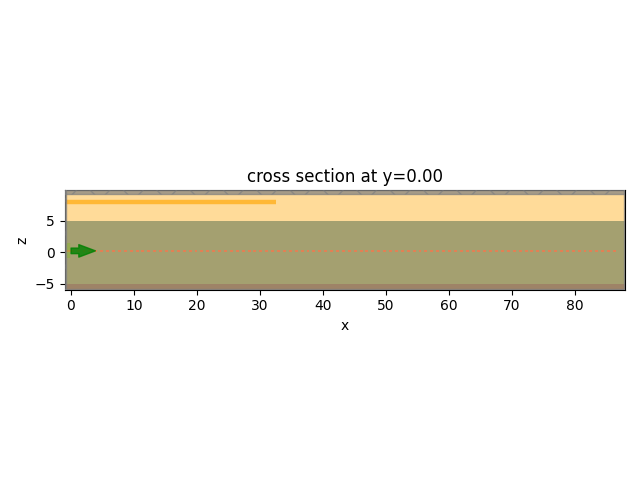

In [13]:
%matplotlib widget
sim0 = make_2d_sim_out(p=0.935, source_x=5)
sim0.plot(y=0, freq=freq0)
plt.show()

The next step is to determine the optimal grating period and source position. We can first get an estimate of the optimal grating period by using the grating equation

$$
\Lambda = \frac{\lambda_0}{n_{\text{eff}} - n_{\text{clad}} \sin \theta},
$$

where
- $\Lambda$ = grating period  
- $\lambda_0$ = free-space wavelength of the incident light  
- $n_{\text{eff}}$ = effective index of the guided mode in the waveguide  
- $n_{\text{clad}}$ = refractive index of the cladding 
- $\theta$ = angle of incidence

$n_{\text{eff}}$ can be approximated by 

$$
n_{\text{eff}} = f n_{etched} + (1-f) n_{unetched},
$$

where $f$ is the filling fraction, $n_{unetched}$ is the effective index of the unetched slab mode, and $n_{etched}$ is the effective index of the etched slab mode. We will calculate $n_{unetched}$ and $n_{etched}$ using our mode solver. The most convenient way of doing so would be to construct mode simulations from the dummy FDTD simulation. For the unetched slab mode, we specify the mode solving plane to be on the left side of the grating region. For the etched slab mode, we specify the plane to be on the right side of the grating region.

In [ ]:
%matplotlib widget
sim0 = make_2d_sim(p=0.935, source_x=5)
sim0.plot(y=0, freq=freq0)
plt.show()

NameError: name 'make_2d_sim' is not defined

In [14]:
# mode_unetched = td.Simulation(
#     sim0,
#     mode_spec=td.ModeSpec(num_modes=1, target_neff=3.47),
#     plane=td.Box(center=(-0.1, 0, 0), size=(0, td.inf, 5 * t_si)),
#     freqs=[freq0],
# )
# data_unetched = web.run(simulation=mode_unetched, task_name="unetched")

# mode_etched = mode_unetched.updated_copy(
#     plane=td.Box(center=(n * 0.5 + 0.1, 0, 0), size=(0, td.inf, 5 * t_si))
# )
# data_etched = web.run(simulation=mode_etched, task_name="etched")


job = web.Job(simulation=sim0, task_name="gc_out_coupling_2d")
sim_2d_out = job.run(path="data/gc2d_out_data.hdf5")
# ce_3d = np.amax(power_db)
# # Fluxes
# power_sub = abs(sim_2d_in["flux_sub"].flux)
# power_ref = abs(sim_2d_in["flux_reflected"].flux)

07:35:43 Eastern Daylight Time Created task 'gc_out_coupling_2d' with task_id   
                               'fdve-903708bc-24cf-4ca0-aeee-60c46f414baa' and  
                               task_type 'FDTD'.

                               View task using web UI at                        
                               ]8;id=180624;https://tidy3d.simulation.cloud/workbench?taskId=fdve-903708bc-24cf-4ca0-aeee-60c46f414baa\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=994087;https://tidy3d.simulation.cloud/workbench?taskId=fdve-903708bc-24cf-4ca0-aeee-60c46f414baa\taskId]8;;\
                               ]8;id=180624;https://tidy3d.simulation.cloud/workbench?taskId=fdve-903708bc-24cf-4ca0-aeee-60c46f414baa\=]8;;\]8;id=288940;https://tidy3d.simulation.cloud/workbench?taskId=fdve-903708bc-24cf-4ca0-aeee-60c46f414baa\fdve]8;;\]8;id=180624;https://tidy3d.simulation.cloud/workbench?taskId=fdve-903708bc-24cf-4ca0-aeee-60c46f414baa\-903708bc-24cf-4ca0-aeee-60c46f414baa']8;;\.

Output()

07:35:51 Eastern Daylight Time status = queued

                               To cancel the simulation, use                    
                               'web.abort(task_id)' or 'web.delete(task_id)' or 
                               abort/delete the task in the web UI. Terminating 
                               the Python script will not stop the job running  
                               on the cloud.

...

Output()

07:36:30 Eastern Daylight Time status = success

                               View simulation result at                        
                               ]8;id=229952;https://tidy3d.simulation.cloud/workbench?taskId=fdve-903708bc-24cf-4ca0-aeee-60c46f414baa\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=665079;https://tidy3d.simulation.cloud/workbench?taskId=fdve-903708bc-24cf-4ca0-aeee-60c46f414baa\taskId]8;;\
                               ]8;id=229952;https://tidy3d.simulation.cloud/workbench?taskId=fdve-903708bc-24cf-4ca0-aeee-60c46f414baa\=]8;;\]8;id=107856;https://tidy3d.simulation.cloud/workbench?taskId=fdve-903708bc-24cf-4ca0-aeee-60c46f414baa\fdve]8;;\]8;id=229952;https://tidy3d.simulation.cloud/workbench?taskId=fdve-903708bc-24cf-4ca0-aeee-60c46f414baa\-903708bc-24cf-4ca0-aeee-60c46f414baa']8;;\.

Output()

07:37:33 Eastern Daylight Time loading simulation from data/gc2d_out_data.hdf5

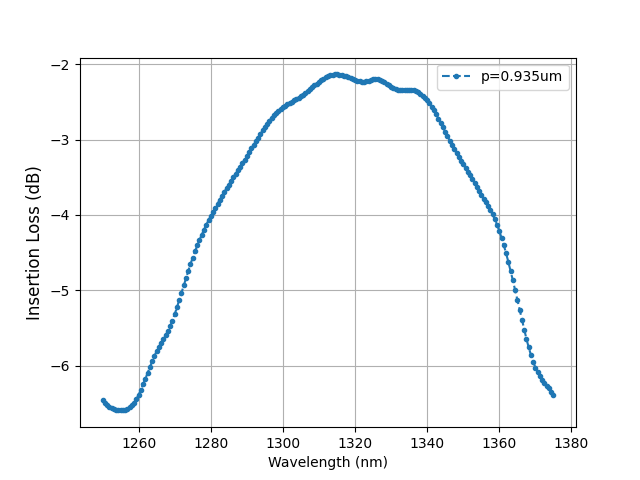

In [15]:
%matplotlib widget
# pow_rx_945 = pow_rx
# pow_rx_935_z150 = pow_rx
flux = sim_2d_out["flux"]
pow_in = 10*np.log10(abs(sim_2d_out["flux"].flux))
plt.close('all')
plt.figure()
plt.plot(ldas*1e3, pow_in, '.--', label='p=0.935um')
# plt.plot(ldas*1e3, pow_rx_945, '.--', label='p=0.945um_z5')
# plt.plot(ldas*1e3, pow_rx_935, '.--', label='p=0.945um_z5')
# plt.plot(ldas*1e3, pow_rx_935_z50, '.--', label='p=0.945um_z50')
# plt.plot(ldas*1e3, pow_rx_935_z150, '.--', label='p=0.945um_z150')

plt.xlabel("Wavelength (nm)")  
plt.ylabel("Insertion Loss (dB)", fontsize=12)
plt.grid()
plt.legend()
plt.show()

In [16]:
%matplotlib widget
# pow_rx_945 = pow_rx
# pow_rx_935_z150 = pow_rx
flux = sim_2d_out["mode"]
pow_rx = 10*np.log10(abs(sim_2d_out["mode"].flux))
plt.close('all')
plt.figure()
plt.plot(ldas*1e3, pow_rx, '.--', label='p=0.935um')
# plt.plot(ldas*1e3, pow_rx_945, '.--', label='p=0.945um_z5')
# plt.plot(ldas*1e3, pow_rx_935, '.--', label='p=0.945um_z5')
# plt.plot(ldas*1e3, pow_rx_935_z50, '.--', label='p=0.945um_z50')
# plt.plot(ldas*1e3, pow_rx_935_z150, '.--', label='p=0.945um_z150')

plt.xlabel("Wavelength (nm)")  
plt.ylabel("Insertion Loss (dB)", fontsize=12)
plt.grid()
plt.legend()
plt.show()

KeyError: 'mode'

<Axes: title={'center': 'cross section at y=0.00'}, xlabel='x', ylabel='z'>

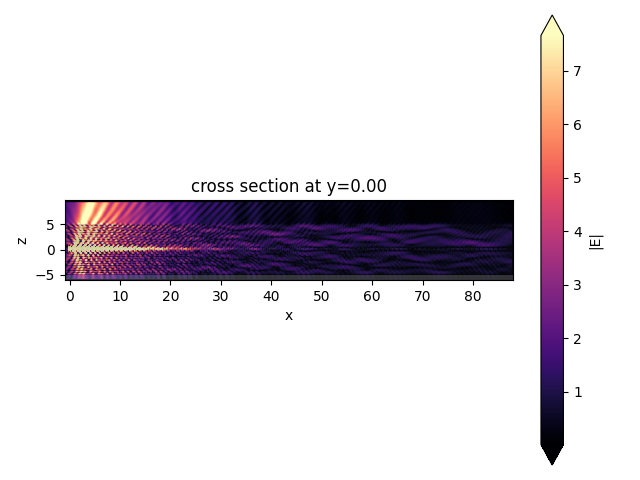

In [17]:
# fig, (ax1, ax2) = plt.subplots(1, 2, tight_layout=True, figsize=(10, 4))
sim_2d_out.plot_field("field_xz", "E", f=freq0, val="abs")

In [ ]:
# Make a near field to far field projector with the near field monitor data
near_field_surface = td.FieldProjectionSurface(monitor=sim_2d_out['field_xz'], 
                                               normal_dir="+")
n2f = td.FieldProjector(sim_data=sim_2d_out, 
                        surfaces=[near_field_surface])

# Compute the far_fields
far_fields = n2f.project_fields(sim_2d_out['monitor_n2f'])

# Compute the scattered cross section
ps = np.abs(far_fields.radar_cross_section.sel(f=freq0).values[0, ...])
# plot the angle dependence
fig, ax = plt.subplots(subplot_kw={"projection": "polar"}, figsize=(4, 4))
ax.plot(thetas, ps, label="simulated")
ax.plot(
    thetas,
    [0, np.max(ps) * 0.7],
    "r--",
    alpha=0.8,
    label="design angle",
)
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.set_yticklabels([])
ax.set_title("Scattered Cross-section (arb. units)", va="bottom")
plt.legend()
plt.show()

ValidationError: 16 validation errors for FieldProjectionSurface
monitor -> type
  unexpected value; permitted: 'FieldMonitor' (type=value_error.const; given=FieldData; permitted=('FieldMonitor',))
monitor -> size
  field required (type=value_error.missing)
monitor -> name
  field required (type=value_error.missing)
monitor -> freqs
  field required (type=value_error.missing)
monitor -> Ex
  extra fields not permitted (type=value_error.extra)
monitor -> Ey
  extra fields not permitted (type=value_error.extra)
monitor -> Ez
  extra fields not permitted (type=value_error.extra)
monitor -> Hx
  extra fields not permitted (type=value_error.extra)
monitor -> Hy
  extra fields not permitted (type=value_error.extra)
monitor -> Hz
  extra fields not permitted (type=value_error.extra)
monitor -> grid_dual_correction
  extra fields not permitted (type=value_error.extra)
monitor -> grid_expanded
  extra fields not permitted (type=value_error.extra)
monitor -> grid_primal_correction
  extra fields

5890 5890
5683 5683


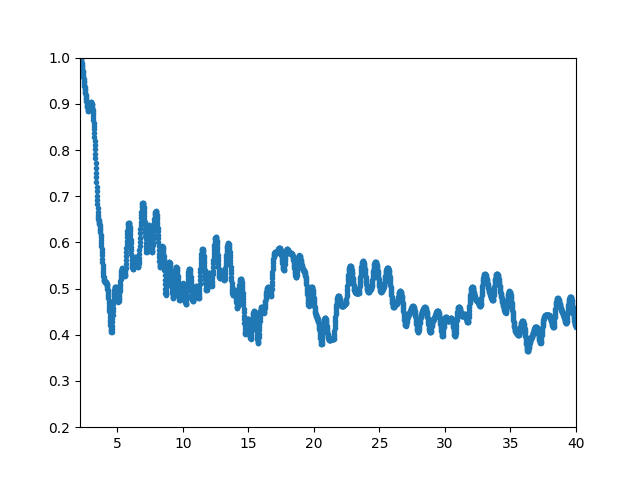

[ 2.14406861  2.15916769  2.17426676 ... 87.89022619 87.90514881
 87.92007143]
Curve fitting failed: Optimal parameters not found: Number of calls to function has reached maxfev = 5000.


In [19]:
from scipy.optimize import curve_fit

field_xz = sim_2d_out['field_xz']
zs = np.array(field_xz.Ex['z'])
xs = np.array(field_xz.Ex['x'])
z_bot_idx = np.argmin(np.abs(zs - t_tox))   # find the index of the z=0 plane
z_top_idx = np.argmin(np.abs(zs - max(zs)))  # find the index of the top plane
Ex_z_wg = np.sum(np.abs(field_xz.Ex[:,:,z_bot_idx:z_top_idx]), axis=2)  # extract the E_x field at z=0 plane
Ex_z_wgs = []

for Ex_z in Ex_z_wg:
    Ex_z = Ex_z.values[0][0]  # normalize the field to the maximum value
    Ex_z_wgs.append(Ex_z)

Ex_z_wgs = np.array(Ex_z_wgs)  # convert to numpy array for plotting
Ex_z_wgs = Ex_z_wgs / np.max(Ex_z_wgs)  # normalize the field to the maximum value

x0_0 = xs[np.argmax(Ex_z_wgs)]
print(len(xs), len(Ex_z_wgs))

xs = xs[np.argmax(Ex_z_wgs):]
Ex_z_wgs = Ex_z_wgs[np.argmax(Ex_z_wgs):]
print(len(xs), len(Ex_z_wgs))
plt.figure()
plt.plot(xs, Ex_z_wgs, '.', label='p=0.935um')
plt.xlim([x0_0, 40])
plt.ylim([0.2, 1.0])
plt.show()

# Define exponential fit function: E(x) = A * exp(-2 * (x - x0)**2 / w**2)
def exp_fit(x, A, x0, w):
    return A * np.exp(-2 * ((x - x0) ** 2) / w ** 2)

# Initial guess: amplitude, center, width
# A0 = np.max(Ex_z_wg)
w0 = 5.0  # initial guess for MFD
print(xs)


try:
    popt, _ = curve_fit(exp_fit, xs, Ex_z_wgs, p0=[1.0, x0_0, w0], maxfev=5000)
    A_fit, x0_fit, w_fit = popt
    MFD = w_fit  # Mode Field Diameter
except RuntimeError as e:
    print("Curve fitting failed:", e)
    A_fit, x0_fit, w_fit, MFD = None, None, None, None

# Plot the fit
# plt.plot(xs, exp_fit(xs, *popt), 'r-', label=f'Exp fit (MFD={MFD:.2f} μm)')

# # Annotate MFD
# plt.annotate(f'MFD = {MFD:.2f} μm', xy=(x0_fit, A_fit/2), xytext=(x0_fit+MFD/2, A_fit/2),
#              arrowprops=dict(arrowstyle="->", color='red'), color='red')

# # Optionally, plot vertical lines at +/- MFD/2 from center
# plt.axvline(x0_fit - MFD/2, color='red', linestyle='--', alpha=0.5)
# plt.axvline(x0_fit + MFD/2, color='red', linestyle='--', alpha=0.5)
# plt.xlabel("x (um)")
# plt.ylabel("E_x (a.u.)", fontsize=12)
# # plt.xlim([1, 50])
# plt.grid()
# plt.legend()
# plt.show()

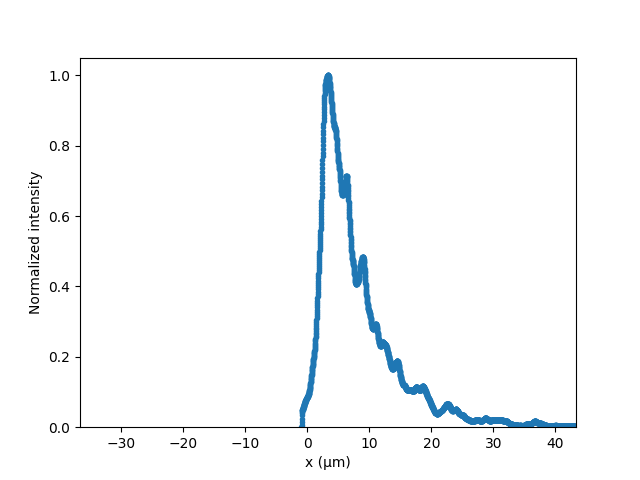

In [20]:
import numpy as np

# coords (assumed in µm)
zs = np.asarray(field_xz.Ex['z'])
xs = np.asarray(field_xz.Ex['x'])

# get complex field arrays, shape ~ (Nx, Nz)
Ex = np.asarray(field_xz.Ex.values).squeeze()
Ey = np.asarray(field_xz.Ey.values).squeeze() if hasattr(field_xz, 'Ey') else 0.0
Ez = np.asarray(field_xz.Ez.values).squeeze() if hasattr(field_xz, 'Ez') else 0.0

# intensity on the x–z plane
I_xz = (np.abs(Ex)**2 + np.abs(Ey)**2 + np.abs(Ez)**2)  # (Nx, Nz)

# choose a z window (e.g., around your detector plane, or from oxide top to free-space)
z_lo = t_tox                      # top of oxide (µm)
z_hi = zs.max()                   # top of sim box or detector plane height
z_lo_idx = np.argmin(np.abs(zs - z_lo))
z_hi_idx = np.argmin(np.abs(zs - z_hi))

# integrate (or average) over that z-range to get lateral profile
I_x = np.trapz(I_xz[:, z_lo_idx:z_hi_idx+1], zs[z_lo_idx:z_hi_idx+1], axis=1)
I_x /= I_x.max()  # normalize

# get center and optionally fit a Gaussian to main lobe
x0 = xs[np.argmax(I_x)]
plt.close('all')
import matplotlib.pyplot as plt
plt.plot(xs, I_x, '.-')
plt.xlim([x0-40, x0+40])  # or whatever window you want
plt.ylim([0, 1.05])
plt.xlabel('x (µm)'); plt.ylabel('Normalized intensity')
plt.show()


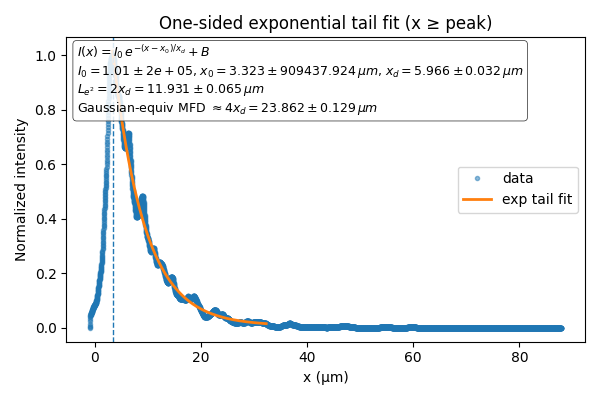

Le2 (1/e^2 decay length): 11.931056328799196 um
Gaussian-equivalent MFD: 23.86211265759839 um


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# one-sided exponential (valid for x >= x0)
def exp_tail(x, I0, x0, xd, B):
    return I0 * np.exp(-(x - x0) / xd) + B

def fit_exponential_tail(xs, I_norm,
                         min_level=0.02,    # stop fitting once we hit this normalized level (cuts noisy floor)
                         x_margin=0.0,      # start a little to the right of the peak if you want
                         show_semilog=True):
    xs = np.asarray(xs).ravel()
    I  = np.asarray(I_norm).ravel()

    # 1) find peak
    i_pk = int(np.argmax(I))
    x0_guess = xs[i_pk]

    # 2) slice data from peak to the right
    m_right = xs >= (x0_guess + x_margin)
    xs_r = xs[m_right]
    I_r  = I[m_right]

    # 3) optionally truncate when signal hits min_level to avoid fitting noise floor
    if I_r.min() < min_level:
        imax = np.argmax(I_r < min_level)
        xs_r = xs_r[:imax]
        I_r  = I_r[:imax]

    # 4) initial guesses
    B_guess  = np.percentile(I_r, 5)          # small floor
    I0_guess = I_r.max() - B_guess
    # estimate xd from slope on semilog: ln(I-B) ≈ -(x-x0)/xd + const
    y = np.log(np.clip(I_r - B_guess, 1e-12, None))
    # do a quick linear fit on the first half of the tail
    nfit = max(6, len(xs_r)//2)
    p = np.polyfit(xs_r[:nfit] - x0_guess, y[:nfit], 1)
    xd_guess = max( ( -1.0 / p[0] ) if p[0] < 0 else (xs_r[-1]-xs_r[0])/3, 0.5 )

    p0 = [I0_guess, x0_guess, xd_guess, B_guess]
    bounds = ([0, x0_guess-2.0, 0, -np.inf], [np.inf, x0_guess+2.0, np.inf, np.inf])

    popt, pcov = curve_fit(exp_tail, xs_r, I_r, p0=p0, bounds=bounds, maxfev=20000)
    I0, x0, xd, B = popt
    perr = np.sqrt(np.clip(np.diag(pcov), 0, np.inf))
    I0_e, x0_e, xd_e, B_e = perr

    # metrics
    Le2 = 2.0 * xd                  # distance to 1/e^2 on the tail
    Le2_e = 2.0 * xd_e
    MFD_eq = 4.0 * xd               # Gaussian-equivalent MFD by matching 1/e^2 radius
    MFD_eq_e = 4.0 * xd_e

    # plot (linear)
    xx = np.linspace(x0, xs_r[-1], 800)
    plt.figure(figsize=(6,4))
    plt.plot(xs, I, '.', alpha=0.5, label='data')
    plt.plot(xx, exp_tail(xx, *popt), '-', lw=2, label='exp tail fit')
    plt.axvline(x0, ls='--', lw=1)
    plt.xlabel('x (µm)'); plt.ylabel('Normalized intensity')
    plt.title('One-sided exponential tail fit (x ≥ peak)')
    plt.legend()
    txt = (
          r"$I(x)=I_0\,e^{-(x-x_0)/x_d}+B$" "\n"
           rf"$I_0={I0:.3g}\pm{I0_e:.1g}$, "
           rf"$x_0={x0:.3f}\pm{x0_e:.3f}\,\mu m$, "
           rf"$x_d={xd:.3f}\pm{xd_e:.3f}\,\mu m$" "\n"
           rf"$L_{{e^2}}=2x_d={Le2:.3f}\pm{Le2_e:.3f}\,\mu m$" "\n"
           rf"Gaussian-equiv MFD $\approx 4x_d={MFD_eq:.3f}\pm{MFD_eq_e:.3f}\,\mu m$")
    plt.text(0.02, 0.98, txt, transform=plt.gca().transAxes,
             va='top', ha='left', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.85, lw=0.5))
    plt.tight_layout()
    plt.show()

    if show_semilog:
        plt.figure(figsize=(6,4))
        plt.semilogy(xs, np.clip(I, 1e-6, None), '.', alpha=0.5, label='data')
        plt.semilogy(xx, np.clip(exp_tail(xx, *popt), 1e-6, None), '-', lw=2, label='exp tail fit')
        plt.axvline(x0, ls='--', lw=1)
        plt.xlabel('x (µm)'); plt.ylabel('Normalized intensity (semilog)')
        plt.title('Semilog check (exponential → straight line)')
        plt.legend(); plt.tight_layout(); plt.show()

    return {
        "I0": I0, "I0_err": I0_e,
        "x0": x0, "x0_err": x0_e,
        "xd": xd, "xd_err": xd_e,
        "Le2": Le2, "Le2_err": Le2_e,
        "MFD_eq": MFD_eq, "MFD_eq_err": MFD_eq_e,
        "popt": popt, "pcov": pcov,
        "x_fit": xs_r
    }

# usage:
result = fit_exponential_tail(xs, I_x, min_level=0.015, x_margin=0.0, show_semilog=False)
print("Le2 (1/e^2 decay length):", result["Le2"], "um")
print("Gaussian-equivalent MFD:", result["MFD_eq"], "um")


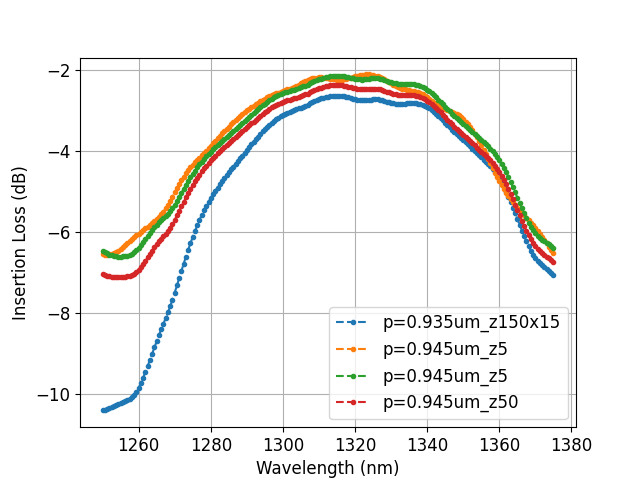

In [ ]:
%matplotlib widget
# pow_rx_945 = pow_rx
pow_rx_935_z150 = pow_rx
flux = sim_2d_in["mode"]
pow_rx = 10*np.log10(abs(sim_2d_in["mode"].flux))
plt.close('all')
plt.figure()
plt.plot(ldas*1e3, pow_rx, '.--', label='p=0.935um_z150x15')
plt.plot(ldas*1e3, pow_rx_945, '.--', label='p=0.945um_z5')
plt.plot(ldas*1e3, pow_rx_935, '.--', label='p=0.945um_z5')
plt.plot(ldas*1e3, pow_rx_935_z50, '.--', label='p=0.945um_z50')
# plt.plot(ldas*1e3, pow_rx_935_z150, '.--', label='p=0.945um_z150')

plt.xlabel("Wavelength (nm)")  
plt.ylabel("Insertion Loss (dB)", fontsize=12)
plt.grid()
plt.legend()
plt.show()

In [1]:
fig, (ax1, ax2) = plt.subplots(1, 2, tight_layout=True, figsize=(10, 4))
sim_2d_in.plot_field("field_xy", "E", f=freq0, val="abs")

NameError: name 'plt' is not defined

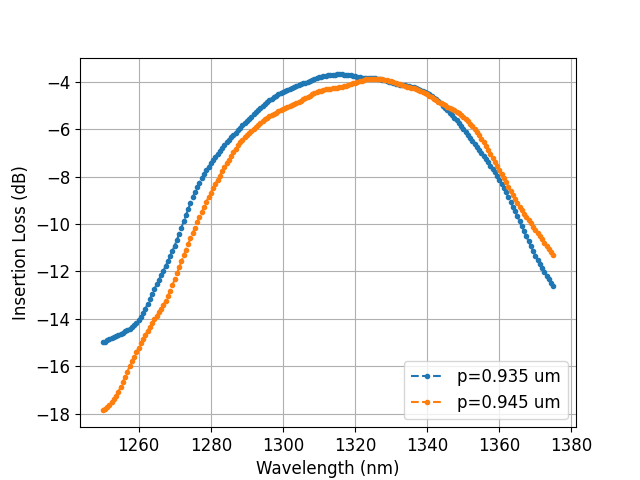

In [63]:
# %matplotlib widget
# flux = sim_2d_in["mode"]
# pow_rx = 10*np.log10(abs(sim_2d_in["mode"].flux))
# plt.figure()
# plt.plot(ldas*1e9, pow_rx)
# plt.xlabel("Wavelength (nm)")  
# plt.show() 


# Coupling Efficiency
mode_amps = sim_2d_in["mode"]
coeffs_f = mode_amps.amps.sel(direction="-")
power = np.abs(coeffs_f.sel(mode_index=0)) ** 2
power_db = 10 * np.log10(power)
plt.close('all')
import matplotlib
matplotlib.rcParams.update({'font.size': 12})
plt.plot(ldas*1e3, power_db_935, '.--', label="p=0.935 um")
plt.plot(ldas*1e3, power_db, '.--', label="p=0.945 um")
plt.legend()
plt.xlabel("Wavelength (nm)", fontsize=12)
plt.ylabel("Insertion Loss (dB)", fontsize=12)
plt.grid()
plt.show() 


After running the mode solving, we can extract the effective indices and hence calculate the appropriate grating period.

In [ ]:
n_unetched = mode_amps.modes_info['n eff'].sel(mode_index=0).values
# print("Effective index of the etched waveguide: ", n_etched)
n_unetched = n_unetched[np.argmin(np.abs(ldas - lda0))]
print("Effective index of the etched waveguide at 1.31 um: ", n_unetched)
# plt.plot(
#     ldas, 
#     mode_amps.modes_info['n eff'],
#     'r.-',
#     label="Mode Effective Index (TE)"
# )

Effective index of the etched waveguide at 1.31 um:  1.7530578


attrs={} wavelength=array([1.31]) core_width=array([18.]) core_thickness=0.4 core_medium=Medium(attrs={}, name=None, frequency_range=None, allow_gain=False, nonlinear_spec=None, modulation_spec=None, heat_spec=None, type='Medium', permittivity=3.8523483076, conductivity=0.0) clad_medium=Medium(attrs={}, name=None, frequency_range=None, allow_gain=False, nonlinear_spec=None, modulation_spec=None, heat_spec=None, type='Medium', permittivity=2.0846739456, conductivity=0.0) box_medium=Medium(attrs={}, name=None, frequency_range=None, allow_gain=False, nonlinear_spec=None, modulation_spec=None, heat_spec=None, type='Medium', permittivity=2.0846739456, conductivity=0.0) slab_thickness=0.0 clad_thickness=1.3609541223404256 box_thickness=1.3609541223404256 side_margin=1.3609541223404256 sidewall_angle=0.0 gap=array([], dtype=float64) sidewall_thickness=0.0 sidewall_medium=None surface_thickness=0.0 surface_medium=None origin=(0.0, 0.0, 0.0) length=1e+30 propagation_axis=0 normal_axis=2 mode_sp

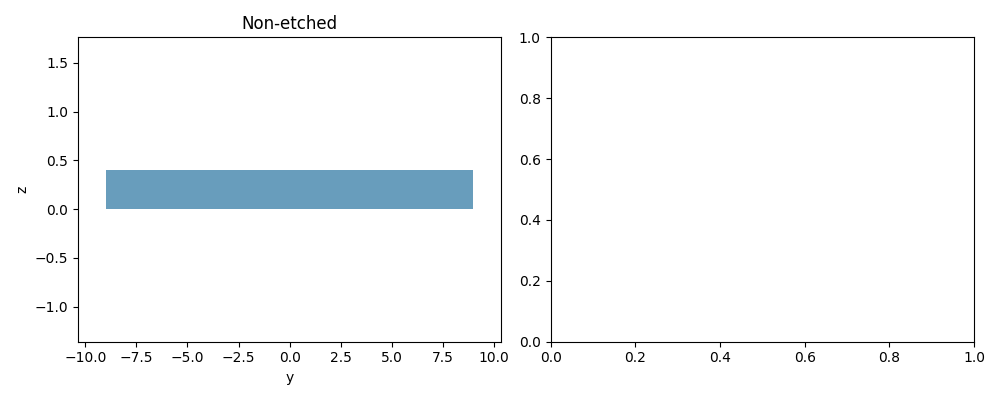

In [143]:
from tidy3d.plugins import waveguide
# Definition of wide non-etched and etched waveguides.
wg_non_etch = waveguide.RectangularDielectric(
        wavelength=lda0,
        core_width=2 * mfd,
        core_thickness=t_si3n4,
        core_medium=si3n4,
        box_medium=sio2,
        clad_medium=sio2,
    )

print(wg_non_etch)
# Take a look at the waveguide cross-sections.
fig, ax = plt.subplots(1, 2, figsize=(10, 4), tight_layout=True)
_ = wg_non_etch.plot_structures(x=0, ax=ax[0])
ax[0].set_aspect("auto")
ax[0].set_title("Non-etched")

# _ = wg_etch.plot_structures(x=0, ax=ax[1])
# ax[1].set_aspect("auto")
# ax[1].set_title("Etched")
# plt.show()

n_o = wg_non_etch.n_eff.values[0, 0]
# n_e = wg_etch.n_eff.values[0, 0]
print(f"Non-etched waveguide effective index: {n_o:.3f}")
# print(f"Etched waveguide effective index: {n_e:.3f}")

To optimize the design, we can perform a [parameter sweep](https://www.flexcompute.com/tidy3d/examples/notebooks/ParameterScan/) over the grating period and source position. To do so, we create a dictionary of simulations and then a [Batch](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.web.api.container.Batch.html). When running the batch, multiple simulations will be running in parallel, making the sweep very time-efficient.

In [144]:
p_list = np.linspace(0.935, 0.945, 10)
source_x_list = np.linspace(3, 5, 11)

sims_2d = {
    f"p={p:.2f};source_x={source_x:.2f}": make_2d_sim(p, source_x)
    for p in p_list
    for source_x in source_x_list
}

batch = web.Batch(simulations=sims_2d)
batch_results = batch.run(path_dir="data")

Output()

17:28:01 Eastern Daylight Time Started working on Batch containing 11 tasks.

17:28:14 Eastern Daylight Time Maximum FlexCredit cost: 1.306 for the whole     
                               batch.

                               Use 'Batch.real_cost()' to get the billed        
                               FlexCredit cost after the Batch has completed.

Output()

17:28:40 Eastern Daylight Time Batch complete.

Output()

After the sweep is finished, we can extract the coupling efficiency from the monitor data. 

In [145]:
freqs = (batch_results[f"p={p_list[0]:.2f};source_x={source_x_list[-1]:.2f}"]["mode"].amps.f.values)
freq0 = freqs[np.argmin(np.abs(freqs - freq0))]

ce = np.array(
    [
        [
            np.abs(
                batch_results[f"p={p:.2f};source_x={source_x:.2f}"]["mode"]
                .amps.sel(f=freq0, direction="-")
                .values.item()
            )
            ** 2
            for source_x in source_x_list
        ]
        for p in p_list
    ]
)

In [147]:
i, j = np.unravel_index(np.argmax(ce), ce.shape)
best_p = p_list[i]
best_source_x = source_x_list[j]
best_ce = ce[i, j]

print(f"Optimal period is {best_p * 1e3} nm.")
print(f"Optimal source_x is {best_source_x} μm.")
print(f"Optimal coupling efficiency is {best_ce * 1e2:.2f}%, or {10 * np.log10(best_ce):.2f} dB.")

ce = np.array(
            np.abs(
                batch_results[f"p={best_p:.2f};source_x={best_source_x:.2f}"]["mode"]
                .amps.sel(direction="-")
                .values
            )
            ** 2
)

Optimal period is 935.0 nm.
Optimal source_x is 3.0 μm.
Optimal coupling efficiency is 1.54%, or -18.13 dB.


In [29]:
print(ce.shape)
plt.figure(figsize=(8, 6))
plt.plot(
    ldas*1e3,
10 * np.log10(ce),  
)

# Find the maximum coupling efficiency
max_ce = np.max(ce)
max_ce_db = 10 * np.log10(max_ce)

# Calculate the 3 dB bandwidth
threshold = max_ce_db - 3
ldas_db = 10 * np.log10(ce)
indices = np.where(ldas_db >= threshold)[0]
ldas_3db = ldas[indices]

# Mark the 3 dB points on the plot
print(ldas_3db[0])
plt.axhline(y=threshold, color='green', linestyle='--', label="3 dB Threshold")
plt.scatter([ldas_3db[0]*1e3, ldas_3db[-1]*1e3], [threshold, threshold], color='red', label="3 dB Points")
plt.legend()
plt.xlabel("Wavelength (nm)", fontsize=12)
plt.ylabel("Coupling Efficiency (dB)", fontsize=12)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.grid()
# plt.xlim(1275, 1375)
# plt.ylim(-15, 0)


# Calculate and print the 3 dB bandwidth
bandwidth_3db = (ldas_3db[-1] - ldas_3db[0]) * 1e3  # Convert to nm
print(f"3 dB Bandwidth: {bandwidth_3db:.2f} nm")

NameError: name 'ce' is not defined

Plot the coupling efficiency as a function of period and source position in a false color map. 

From the result we can determine the optimal grating period and source position. 

## 3D Design of the Grating Coupler

The 2D design shows promising results. Now we can convert it to 3D for verification and potentially further optimization. 

The single-mode waveguide has a width of 500 nm. The waveguide and the grating are connected via a linear taper. The longer the taper, the lower the loss in the taper region but the larger the footprint. Here we use a 50 μm linear taper with reasonably low loss. 

To enable additional optimization, we create a function similar to before. 

In [7]:
w_wg = 0.8  # waveguide width
w_grating = 20  # grating width is set to the mode field diameter
l_taper = 1222.368  # length of the linear taper

l_taper = 200.368  # length of the linear taper

def make_3d_sim(p: float, source_x: float) -> td.Simulation:
    """Function to create a 2D simulation given the grating period and source position"""

    source_gap = 0.5

    # define a gaussian beam source
    source = td.GaussianBeam(
        size=(2 * mfd, 2 * mfd, 0),
        center=[source_x, 0, t_tox + source_gap],
        source_time=td.GaussianPulse(freq0=freq0, fwidth=fwidth),
        angle_theta=theta,
        direction="-",
        waist_radius=mfd / 2,
        pol_angle=np.pi / 2,  # 90 degree polarization angle for TE polarization
    )

    # define a mode monitor
    mode_monitor = td.ModeMonitor(
        center=(-
                 -buffer - l_taper + 0.5, 0, t_si3n4 / 2),
        size=(0, 4 * w_wg, 6 * t_si3n4),
        freqs=freqs,
        mode_spec=td.ModeSpec(num_modes=1, target_neff=n_si3n4),
        name="mode",
    )

    l_grating = n * p  # length of the grating region

    gratings = 0
    for i in range(n):
        gratings += td.Box(
            center=(ff * p / 2 + i * p, 0, t_si3n4 - etch_depth / 2),
            size=(p * ff, w_grating, etch_depth),
        )

    # create the grating structure
    gratings = td.Structure(geometry=gratings, medium=si3n4)

    vertices = [
        (0, w_grating / 2),
        (0, -w_grating / 2),
        (-l_taper, -w_wg / 2),
        (-l_taper - 2 * buffer, -w_wg / 2),
        (-l_taper - 2 * buffer, w_wg / 2),
        (-l_taper, w_wg / 2),
    ]
    taper = td.Structure(
        geometry=td.PolySlab(vertices=vertices, axis=2, slab_bounds=(0, t_si3n4)), medium=si3n4
    )

    # create a box to represent the simulation domain box
    sim_box = td.Box.from_bounds(
        rmin=(-buffer - l_taper, -w_grating / 2 - buffer, -t_box - buffer),
        rmax=(l_grating + buffer, w_grating / 2 + buffer, t_si3n4 + t_tox + buffer),
    )

    run_time = 20e-12  # simulation run time

    # construct simulation
    sim = td.Simulation(
        center=sim_box.center,
        size=sim_box.size,
        grid_spec=td.GridSpec.auto(
            min_steps_per_wvl=15, wavelength=lda0
        ),  # use a fine grid to ensure the small features are well resolved
        structures=[
            tox,
            gratings,
            # etched_waveguide,
            taper,
            box,
            substrate,
        ],
        sources=[source],
        monitors=[mode_monitor],
        run_time=run_time,
        symmetry=(0, -1, 0),
    )

    return sim

In [8]:
def make_3d_sim_out(p: float, source_x: float) -> td.Simulation:
    """Function to create a 3D simulation for output field/flux visualization."""

    source_gap = 5  # gap distance between the source and the top oxide

    # Define a mode source at the waveguide facet
    source = td.ModeSource(
        size=(0, 4 * w_wg, 6 * t_si3n4),
        center=(-buffer - l_taper + 0.5, 0, t_si3n4 / 2),
        source_time=td.GaussianPulse(freq0=freq0, fwidth=fwidth),
        direction="+",
        mode_spec=td.ModeSpec(num_modes=1, target_neff=n_si3n4),
        mode_index=0,
    )

    # Define a flux monitor above the grating
    flux_monitor = td.FluxMonitor(
        center=[55*0.5, 0, t_tox + source_gap],
        size=(55, w_grating, 0),
        freqs=freqs,
        name="mode",
    )

    # Add a field monitor for visualization
    field_monitor_xy = td.FieldMonitor(
        center=[55*0.5, 0, t_tox + source_gap],
        size=(55, w_grating, 0),
        freqs=freq0,
        name="field_xy",
    )

    l_grating = n * p  # length of the grating region

    # Create the grating geometries
    gratings = 0
    for i in range(n):
        gratings += td.Box(
            center=(ff * p / 2 + i * p, 0, t_si3n4 - etch_depth / 2),
            size=(p * ff, w_grating, etch_depth),
        )
    gratings = td.Structure(geometry=gratings, medium=si3n4)

    # Taper geometry
    vertices = [
        (0, w_grating / 2),
        (0, -w_grating / 2),
        (-l_taper, -w_wg / 2),
        (-l_taper - 2 * buffer, -w_wg / 2),
        (-l_taper - 2 * buffer, w_wg / 2),
        (-l_taper, w_wg / 2),
    ]
    taper = td.Structure(
        geometry=td.PolySlab(vertices=vertices, axis=2, slab_bounds=(0, t_si3n4)), medium=si3n4
    )

    # Simulation domain
    sim_box = td.Box.from_bounds(
        rmin=(-buffer - l_taper, -w_grating / 2 - buffer, -t_box - buffer),
        rmax=(l_grating + buffer, w_grating / 2 + buffer, t_si3n4 + t_tox + buffer + source_gap),
    )

    run_time = 12e-12  # simulation run time

    sim = td.Simulation(
        center=sim_box.center,
        size=sim_box.size,
        grid_spec=td.GridSpec.auto(
            min_steps_per_wvl=15, wavelength=lda0
        ),
        structures=[
            tox,
            gratings,
            taper,
            box,
            substrate,
        ],
        sources=[source],
        monitors=[flux_monitor, field_monitor_xy],
        run_time=run_time,
        symmetry=(0, -1, 0),
    )

    return sim

Generate the simulation using the optimal parameters from the 2D design. 

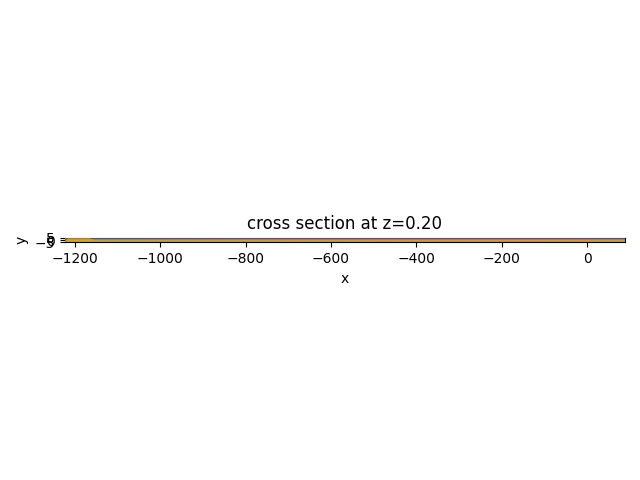

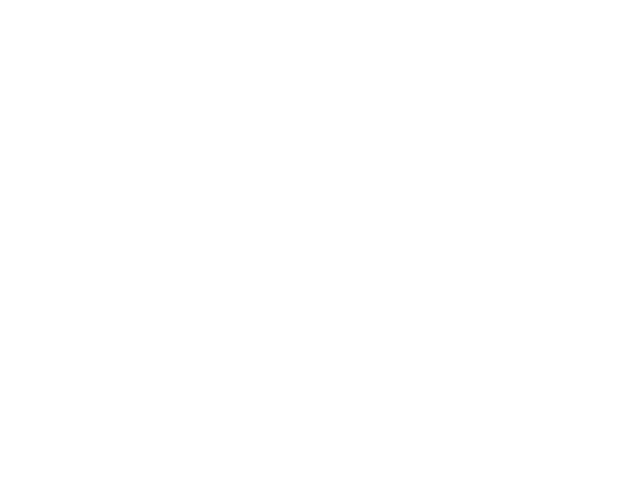

In [123]:
sim_3d = make_3d_sim(p=best_p, source_x=best_source_x)
plt.figure()
sim_3d.plot(z = t_si3n4/2)
plt.show()

<Figure size 640x480 with 0 Axes>

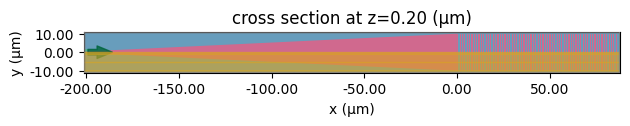

In [9]:
sim_3d = make_3d_sim_out(p=0.935, source_x=5)
plt.figure()
sim_3d.plot(z = t_si3n4/2)
plt.show()

Run the 3D simulation.

In [10]:
sim_data = web.run(simulation=sim_3d, task_name="3D_GC")

11:19:46 Eastern Daylight Time Created task '3D_GC' with task_id                
                               'fdve-d75c1c8b-5e15-43e7-9608-49813b958b29' and  
                               task_type 'FDTD'.

                               View task using web UI at                        
                               ]8;id=530370;https://tidy3d.simulation.cloud/workbench?taskId=fdve-d75c1c8b-5e15-43e7-9608-49813b958b29\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=147887;https://tidy3d.simulation.cloud/workbench?taskId=fdve-d75c1c8b-5e15-43e7-9608-49813b958b29\taskId]8;;\
                               ]8;id=530370;https://tidy3d.simulation.cloud/workbench?taskId=fdve-d75c1c8b-5e15-43e7-9608-49813b958b29\=]8;;\]8;id=57645;https://tidy3d.simulation.cloud/workbench?taskId=fdve-d75c1c8b-5e15-43e7-9608-49813b958b29\fdve]8;;\]8;id=530370;https://tidy3d.simulation.cloud/workbench?taskId=fdve-d75c1c8b-5e15-43e7-9608-49813b958b29\-d75c1c8b-5e15-43e7-9608-49813b958b29']8;;\.

                               Task folder: ]8;id=16717;https://tidy3d.simulation.cloud/folders/8993e9fd-16eb-42bd-a54a-7270ad3d7232\'default']8;;\.

Output()

11:19:49 Eastern Daylight Time Maximum FlexCredit cost: 56.102. Minimum cost    
                               depends on task execution details. Use           
                               'web.real_cost(task_id)' to get the billed       
                               FlexCredit cost after a simulation run.

...

Output()

11:31:27 Eastern Daylight Time status = success

11:31:29 Eastern Daylight Time View simulation result at                        
                               ]8;id=360944;https://tidy3d.simulation.cloud/workbench?taskId=fdve-d75c1c8b-5e15-43e7-9608-49813b958b29\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=821581;https://tidy3d.simulation.cloud/workbench?taskId=fdve-d75c1c8b-5e15-43e7-9608-49813b958b29\taskId]8;;\
                               ]8;id=360944;https://tidy3d.simulation.cloud/workbench?taskId=fdve-d75c1c8b-5e15-43e7-9608-49813b958b29\=]8;;\]8;id=741984;https://tidy3d.simulation.cloud/workbench?taskId=fdve-d75c1c8b-5e15-43e7-9608-49813b958b29\fdve]8;;\]8;id=360944;https://tidy3d.simulation.cloud/workbench?taskId=fdve-d75c1c8b-5e15-43e7-9608-49813b958b29\-d75c1c8b-5e15-43e7-9608-49813b958b29']8;;\.

Output()

11:31:34 Eastern Daylight Time loading simulation from simulation_data.hdf5

Plot the coupling efficiency as a function of wavelength. Compared to 2D, the coupling efficiency of -4 dB is slightly lower in 3D. This is because of two factors: 1. the taper introduces some loss during the mode size conversion down to the single-mode waveguide; 2. The optimal parameters in 2D can differ slightly from the optimal parameters in 3D. 

One can perform a parameter sweep similar to the 2D case to further optimize the design. For simplicity, we skip this part in this notebook.

In [64]:
np.max(10*np.log10(abs(sim_data["mode"].flux)))

<xarray.DataArray ()> Size: 4B
array(-2.1820946, dtype=float32)

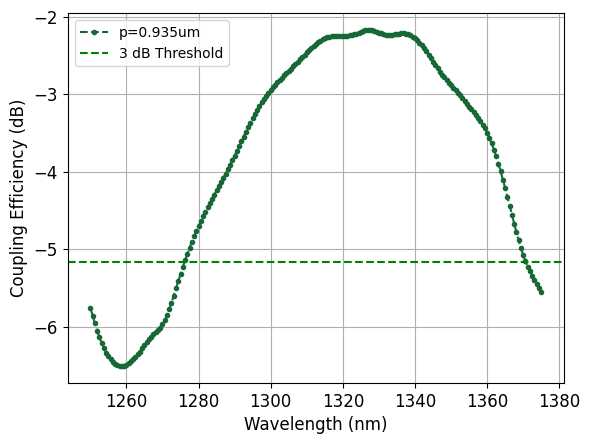

In [14]:
# ce_3d = 10 * np.log10(np.abs(sim_data["mode"].flux))
# flux = sim_data["mode"]
ce_3d = 10*np.log10(abs(sim_data["mode"].flux))
plt.close('all')

plt.figure()
plt.plot(ldas*1e3, ce_3d, '.--', label='p=0.935um')
# plt.plot(ldas*1e3, 10 * np.log10(ce), '.-')

# # plt.ylim(-12, 0)
# plt.xlabel("Wavelength (μm)")
# plt.ylabel("Coupling efficiency (dB)")
# plt.grid()
# plt.show()
    

# Find the maximum coupling efficiency
max_ce_3d_dB = np.max(ce_3d)
# max_ce_3d_db = 10 * np.log10(max_ce_3d)
# print('Max coupling effiiciency is %.2f dB' % max_ce_3d_db)

# Calculate the 3 dB bandwidth
threshold_3d = max_ce_3d_dB - 3
indices_3d = np.where(ce_3d >= threshold_3d)[0]
ldas_3db_3d = ldas[indices_3d]
# Calculate and print the 3 dB bandwidth
# bandwidth_3db_3d = (ldas_3db_3d[-1] - ldas_3db_3d[0]) * 1e3  # Convert to nm

# Mark the 3 dB points on the plot
plt.axhline(y=threshold_3d, color='green', linestyle='--', label="3 dB Threshold")
# plt.scatter([ldas_3db_3d[0]*1e3, ldas_3db_3d[-1]*1e3], [threshold_3d, threshold_3d], color='red', label="{:.3f} nm".format(bandwidth_3db_3d))
plt.legend()
plt.xlabel("Wavelength (nm)", fontsize=12)
plt.ylabel("Coupling Efficiency (dB)", fontsize=12)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.grid()
# plt.xlim(1200, 1400)
# plt.ylim(-15, 0)  # Set the y-axis limits



# print(f"3 dB Bandwidth: {bandwidth_3db_3d:.2f} nm")

In [17]:
print(np.shape(sim_data['field_xy'].Ex))

(2191, 799, 1, 1)


<Axes: title={'center': 'cross section at z=10.00 (μm)'}, xlabel='x (μm)', ylabel='y (μm)'>

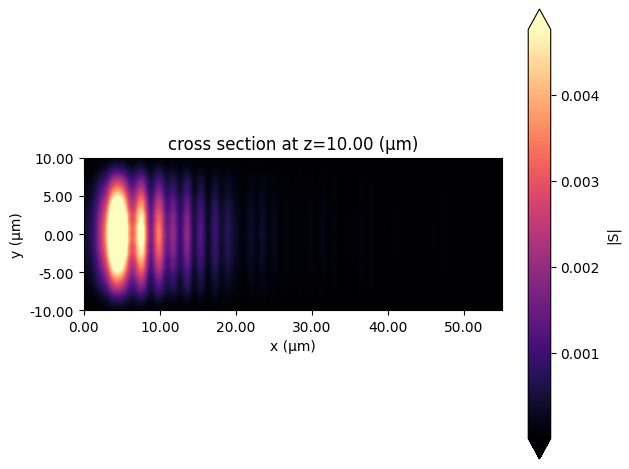

In [ ]:
# fig, (ax1, ax2) = plt.subplots(1, 2, tight_layout=True, figsize=(10, 4))
sim_data.plot_field("field_xy", "S", f=freq0, val="abs")

In [21]:
# get complex field arrays, shape ~ (Nx, Nz)
Ex = np.asarray(sim_data['field_xy'].Ex.values).squeeze()
Ey = np.asarray(sim_data['field_xy'].Ey.values).squeeze()
x = np.asarray(sim_data['field_xy'].Ex.x)
y = np.asarray(sim_data['field_xy'].Ex.y)

In [ ]:
print(np.shape(sim_data))
sim_data['field_xy'].to_zbf(fname = './gc.zbf',
                            n_x = 2048,
                            n_y = 1024,
                            freq = freq0,
                            )

(2191, 799, 1, 1)


12:23:42 Eastern Daylight Time WARNING: 'FieldData.to_zbf()' is currently an    
                               experimental feature. If any issues are          
                               encountered, please contact Flexcompute support  
                               'https://www.flexcompute.com/tidy3d/technical-sup
                               port/'                                           

c:\Users\SiPhox\miniforge3\envs\tidy3denv\Lib\site-packages\scipy\interpolate\_interpolate.py:479: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]


(<xarray.ScalarFieldDataArray (x: 2048, y: 1024)> Size: 34MB
 array([[nan+nanj, nan+nanj, nan+nanj, ..., nan+nanj, nan+nanj, nan+nanj],
        [nan+nanj, nan+nanj, nan+nanj, ..., nan+nanj, nan+nanj, nan+nanj],
        [nan+nanj, nan+nanj, nan+nanj, ..., nan+nanj, nan+nanj, nan+nanj],
        ...,
        [nan+nanj, nan+nanj, nan+nanj, ..., nan+nanj, nan+nanj, nan+nanj],
        [nan+nanj, nan+nanj, nan+nanj, ..., nan+nanj, nan+nanj, nan+nanj],
        [nan+nanj, nan+nanj, nan+nanj, ..., nan+nanj, nan+nanj, nan+nanj]])
 Coordinates:
     f        float64 8B 2.288e+14
   * x        (x) float64 16kB -0.02513 0.001755 0.02865 ... 54.97 54.99 55.02
   * y        (y) float64 8kB -10.02 -10.0 -9.985 -9.966 ... 9.985 10.0 10.02,
 <xarray.ScalarFieldDataArray (x: 2048, y: 1024)> Size: 34MB
 array([[nan+nanj, nan+nanj, nan+nanj, ..., nan+nanj, nan+nanj, nan+nanj],
        [nan+nanj, nan+nanj, nan+nanj, ..., nan+nanj, nan+nanj, nan+nanj],
        [nan+nanj, nan+nanj, nan+nanj, ..., nan+nanj, nan

In [66]:
from to_zbf import to_zbf
e_x, e_y = to_zbf(sim_data['field_xy'],
    fname = './gc.zbf',
    n_x = 2048,
    n_y = 1024,
    freq = freq0,
)

FieldDataset(attrs={}, type='FieldDataset', Ex=<xarray.ScalarFieldDataArray (x: 512, y: 1024, z: 1, f: 1)> Size: 8MB
array([[[[0.00051203+0.j]],

        [[0.00103156+0.j]],

        [[0.00155108+0.j]],

        ...,

        [[0.00042198+0.j]],

        [[0.00028036+0.j]],

        [[0.00013881+0.j]]],


       [[[0.00051204+0.j]],

        [[0.00103158+0.j]],

        [[0.00155113+0.j]],
...
        [[0.00042199+0.j]],

        [[0.00028037+0.j]],

        [[0.00013881+0.j]]],


       [[[0.00051203+0.j]],

        [[0.00103156+0.j]],

        [[0.00155108+0.j]],

        ...,

        [[0.00042198+0.j]],

        [[0.00028036+0.j]],

        [[0.00013881+0.j]]]])
Coordinates:
  * x        (x) float64 4kB -5.065 -5.045 -5.025 -5.006 ... 5.025 5.045 5.065
  * y        (y) float64 8kB -5.19 -5.18 -5.17 -5.16 ... 5.16 5.17 5.18 5.19
  * z        (z) int32 4B 0
  * f        (f) float64 8B 3.315e+14
Attributes:
    long_name:  field value, Ey=<xarray.ScalarFieldDataArray (x: 512, y: 1024,

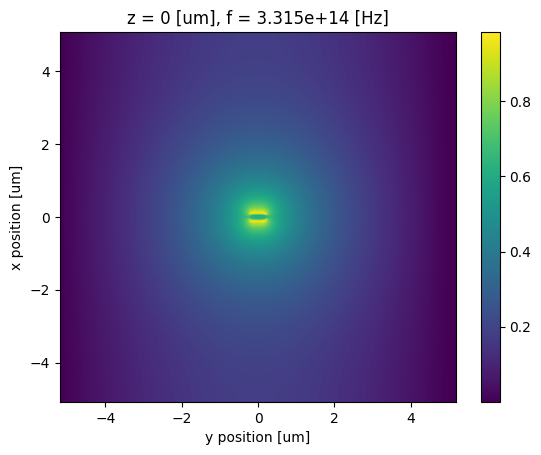

In [72]:
from from_zbf import from_zbf

ssc_data = from_zbf(r'C:\users\SiPhox\Downloads\W150nm_SSC_5um_top_and_bottom_clad_400nm_Si3N4.zbf',
                                    dim1 = 'x',
                                    dim2 = 'y')
(ssc_data.Ex.abs + ssc_data.Ey.abs).plot()
ssc_data

228849204580152.66

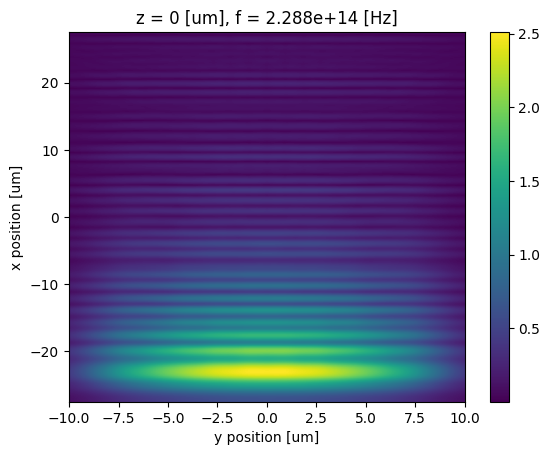

In [77]:
gc_data = from_zbf(r'./gc.zbf',
                  dim1 = 'x',
                  dim2 = 'y')
(gc_data.Ex.abs + gc_data.Ey.abs).plot()

f

In [32]:
atol_rel_uniform=1e-6

Ny, Nx = Ex.shape
assert Ey.shape == (Ny, Nx), "Ey must match Ex shape"

# x = x*1e-6
# y = y*1e-6
# --- check uniform sampling ---
dxs = np.diff(x)
dys = np.diff(y)
dx = float(np.mean(dxs))
print(dx)
dy = float(np.mean(dys))
if not (np.allclose(dxs, dx, rtol=0, atol=abs(dx)*atol_rel_uniform) and
        np.allclose(dys, dy, rtol=0, atol=abs(dy)*atol_rel_uniform)):
    raise ValueError("x or y are not uniformly sampled; resample before writing ZBF.")


2.51344087920367e-08


ValueError: x or y are not uniformly sampled; resample before writing ZBF.

## Final Remarks

In this notebook, we use the Gaussian beam as the source and use a mode monitor to measure the coupling efficiency. Due to reciprocity, one can use a mode source at the waveguide as excitation and then take the radiated field and do a mode overlap with a Gaussian profile to calculate the same value. In addition, in this setup, one can also perform near field to far field projection by using monitors like [FieldProjectionAngleMonitor](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.FieldProjectionAngleMonitor.html) to investigate he radiation angle of the grating if that's of interest.

In the simulations we only focus on the coupling efficiency and hence only use a [ModeMonitor](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.ModeMonitor.html) to measure the power of the fundamental mode in the waveguide. One can also add [FieldMonitors](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.FieldMonitor.html) in the simulations to help visualize the field distribution if needed. 